In [39]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import os
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts


def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    print(filepath)
    df = pd.read_csv(filepath)
    unit_concepts = set()
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        
        unit_concepts.update(concepts)
        raw_concepts.extend(concepts)
        
    
    return unit_concepts #, raw_concepts


def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
        
    
    return unit_concepts #, raw_concepts
 

In [84]:
def load_global_concepts_from_csv(csv_path):
    """
    Returns a set of all concepts explained in this CSV
    """
    
    unit_concepts = load_csv_data(csv_path)  # unit -> set(concepts)

    global_concepts = set()
    for concepts in unit_concepts.values():
        global_concepts.update(concepts)

    return global_concepts


base_dir = "/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls/"
def load_all_cluster_concepts(sparsity_dir):
    """
    Load all unique concepts across c1, c2, c3 for a sparsity
    """
    cluster_files = [
        "Cluster1IOUS1024N.csv",
        "Cluster2IOUS1024N.csv",
        "Cluster3IOUS1024N.csv",
    ]

    all_concepts = set()

    for fname in cluster_files:
        fpath = os.path.join(sparsity_dir, fname)
       
        try:
            unit_concepts = load_csv_data(fpath)  # unit -> set(concepts)
            for concepts in unit_concepts.values():
                all_concepts.update(concepts)
        except:
            continue
    return all_concepts


sparsity_to_concepts = {}
critical_tokens =  [
    "a", "an", "the", "this", "that", "these", "those",
    "some", "any", "each", "every", "no",
    "i", "you", "he", "she", "it", "they",
    "me", "him", "her", "them",
    "his", "hers", "their", "its",
    "someone", "something", "nobody",
    "in", "on", "at", "by", "for", "from", "to", "with",
    "about", "into", "through", "over", "under",
    "between", "near", "inside", "outside",
    "and", "or", "but", "because", "while", "if", "though", "although", "so",
    "is", "am", "are", "was", "were", "be", "being", "been",
    "do", "does", "did",
    "have", "has", "had",
    "can", "could", "will", "would", "should", "may", "might", "must",
    "not", "none", "never", "nothing", "least", "most", "all",
    "there", "here", "just", "only", "also", "very",
    ".", ",", ":", ";", "!", "?"
]
def label_concept(concept: str):
    """
    Returns 'c' for critical or 'nc' for non-critical
    """
    # POS tags are always critical
    if ":tag:" in concept:
        return "c"

    # Overlap / structural features
    if concept.startswith("oth:"):
        return "c"

    # Token-level concepts
    if ":tok:" in concept:
        token = concept.split(":tok:")[-1]
        return "c" if token in critical_tokens else "nc"

    # Default fallback
    return "nc"



for sparsity in os.listdir(base_dir):
    sparsity_path = os.path.join(base_dir, sparsity)



    try:
        s = float(sparsity.split("%")[0])
        
    except ValueError:
        continue

    concepts = load_all_cluster_concepts(sparsity_path)
    sparsity_to_concepts[s] = concepts

    print(f"Sparsity {s}: {len(concepts)} total concepts")

sparsities = list(sparsity_to_concepts.keys())
s_prev = sparsities[0]
for i in range(len(sparsities) - 1):
    s_next = sparsities[i + 1]

    prev_concepts = sparsity_to_concepts[s_prev]
    next_concepts = sparsity_to_concepts[s_next]

    removed = prev_concepts - next_concepts
    added   = next_concepts - prev_concepts

    removed_concepts_by_step[(s_prev, s_next)] = removed

    print(f"\nSparsity {s_prev} → {s_next}")
    print(f"Removed concepts: {len(removed)}")
    print(f"Added concepts:   {len(added)}")

    # Show a few examples
    
    func=0
    for i in removed:
        if label_concept(i) == 'c': # in critical_tokens:
            func += 1
    print(f"Number functional removed: {func}/ {len(removed)}")
    
    func = 0
    for i in added:
        if label_concept(i) == 'c': # in critical_tokens:
            func += 1
    print(f"Number functional added: {func}/ {len(added)}")
    


Sparsity 0.0: 319 total concepts
Sparsity 0.27243559109531656: 334 total concepts
Sparsity 0.4451998451203647: 279 total concepts
Sparsity 0.5874358855616119: 280 total concepts
Sparsity 0.6851741293419538: 256 total concepts
Sparsity 0.783612596400868: 0 total concepts

Sparsity 0.0 → 0.27243559109531656
Removed concepts: 105
Added concepts:   120
Number functional removed: 15/ 105
Number functional added: 14/ 120

Sparsity 0.0 → 0.4451998451203647
Removed concepts: 106
Added concepts:   66
Number functional removed: 9/ 106
Number functional added: 10/ 66

Sparsity 0.0 → 0.5874358855616119
Removed concepts: 108
Added concepts:   69
Number functional removed: 12/ 108
Number functional added: 12/ 69

Sparsity 0.0 → 0.6851741293419538
Removed concepts: 128
Added concepts:   65
Number functional removed: 17/ 128
Number functional added: 9/ 65

Sparsity 0.0 → 0.783612596400868
Removed concepts: 319
Added concepts:   0
Number functional removed: 98/ 319
Number functional added: 0/ 0


In [98]:
#clusterwise but not unique to each cluster
#cluster wise
import os

base_dir = "/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls/"

cluster_files = [
    "Cluster1IOUS1024N.csv",
    "Cluster2IOUS1024N.csv",
    "Cluster3IOUS1024N.csv",
]

critical_tokens = [
    "a", "an", "the", "this", "that", "these", "those",
    "some", "any", "each", "every", "no",
    "i", "you", "he", "she", "it", "they",
    "me", "him", "her", "them",
    "his", "hers", "their", "its",
    "someone", "something", "nobody",
    "in", "on", "at", "by", "for", "from", "to", "with",
    "about", "into", "through", "over", "under",
    "between", "near", "inside", "outside",
    "and", "or", "but", "because", "while", "if", "though", "although", "so",
    "is", "am", "are", "was", "were", "be", "being", "been",
    "do", "does", "did",
    "have", "has", "had",
    "can", "could", "will", "would", "should", "may", "might", "must",
    "not", "none", "never", "nothing", "least", "most", "all",
    "there", "here", "just", "only", "also", "very",
    ".", ",", ":", ";", "!", "?"
]

def label_concept(concept: str):
    """Return 'c' for critical or 'nc' for non-critical"""
    if ":tag:" in concept:
        return "c"
    if concept.startswith("oth:"):
        return "c"
    if ":tok:" in concept:
        token = concept.split(":tok:")[-1]
        return "c" if token in critical_tokens else "nc"
    return "nc"

def load_cluster_concepts(sparsity_dir, cluster_file):
    """Load concepts from a single cluster CSV"""
    try:
        unit_concepts = load_csv_data(os.path.join(sparsity_dir, cluster_file))
        all_concepts = set()
        for concepts in unit_concepts.values():
            all_concepts.update(concepts)
        return all_concepts
    except Exception:
        return set()

# Load concepts per cluster per sparsity
sparsity_to_cluster_concepts = {}  # sparsity -> cluster -> set(concepts)

for sparsity in os.listdir(base_dir):
    sparsity_path = os.path.join(base_dir, sparsity)
    try:
        s = float(sparsity.split("%")[0])
    except ValueError:
        continue

    cluster_concepts = {}
    for i, fname in enumerate(cluster_files, 1):
        cluster_name = f"c{i}"
        concepts = load_cluster_concepts(sparsity_path, fname)
        cluster_concepts[cluster_name] = concepts
    

    sparsity_to_cluster_concepts[s] = cluster_concepts
    total = sum(len(c) for c in cluster_concepts.values())
    print(f"Sparsity {s}: {total} total concepts across clusters")

# Track added/removed functional concepts per cluster between sparsity steps
removed_concepts_by_step = {}
added_concepts_by_step = {}

sparsities = sorted(sparsity_to_cluster_concepts.keys())
for i in range(-1, len(sparsities) - 1):
    s_prev, s_next = sparsities[0], sparsities[i + 1]

    print(f"\nSparsity {s_prev} → {s_next}")

    for cluster in cluster_files:
        c_name = f"c{cluster_files.index(cluster) + 1}"
        prev = sparsity_to_cluster_concepts[s_prev][c_name]
        next_ = sparsity_to_cluster_concepts[s_next][c_name]

        removed = prev - next_
        added = next_ - prev

        removed_func = sum(1 for c in removed if label_concept(c) == 'c')
        added_func = sum(1 for c in added if label_concept(c) == 'c')

        print(f"\nCluster {c_name}:")
        print(f"  Removed concepts: {len(removed)} (Functional: {removed_func})")
        print(f"  Added concepts:   {len(added)} (Functional: {added_func})")
        print(f"  Prev Total concepts:   {len(prev)}")
        print(f"  Next Total concepts:   {len(next_)}")
        
        new_func = sum(1 for c in next_ if label_concept(c) == 'c')
        print(f"  % of func:   {new_func}/{len(next_)} = {new_func/len(next_)}")
        print(f"  % of non func:   {len(next_) - new_func}/{len(next_)} = {1 - (new_func/len(next_))}")

        removed_concepts_by_step[(s_prev, s_next, c_name)] = removed
        added_concepts_by_step[(s_prev, s_next, c_name)] = added


Sparsity 0.0: 604 total concepts across clusters
Sparsity 0.27243559109531656: 626 total concepts across clusters
Sparsity 0.4451998451203647: 555 total concepts across clusters
Sparsity 0.5874358855616119: 546 total concepts across clusters
Sparsity 0.6851741293419538: 386 total concepts across clusters
Sparsity 0.783612596400868: 0 total concepts across clusters

Sparsity 0.0 → 0.0

Cluster c1:
  Removed concepts: 0 (Functional: 0)
  Added concepts:   0 (Functional: 0)
  Prev Total concepts:   205
  Next Total concepts:   205
  % of func:   83/205 = 0.40487804878048783
  % of non func:   122/205 = 0.5951219512195122

Cluster c2:
  Removed concepts: 0 (Functional: 0)
  Added concepts:   0 (Functional: 0)
  Prev Total concepts:   186
  Next Total concepts:   186
  % of func:   76/186 = 0.40860215053763443
  % of non func:   110/186 = 0.5913978494623655

Cluster c3:
  Removed concepts: 0 (Functional: 0)
  Added concepts:   0 (Functional: 0)
  Prev Total concepts:   213
  Next Total conc

ZeroDivisionError: division by zero

In [99]:
#cluster wise
import os

base_dir = "/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls/"

cluster_files = [
    "Cluster1IOUS1024N.csv",
    "Cluster2IOUS1024N.csv",
    "Cluster3IOUS1024N.csv",
]

critical_tokens = [
    "a", "an", "the", "this", "that", "these", "those",
    "some", "any", "each", "every", "no",
    "i", "you", "he", "she", "it", "they",
    "me", "him", "her", "them",
    "his", "hers", "their", "its",
    "someone", "something", "nobody",
    "in", "on", "at", "by", "for", "from", "to", "with",
    "about", "into", "through", "over", "under",
    "between", "near", "inside", "outside",
    "and", "or", "but", "because", "while", "if", "though", "although", "so",
    "is", "am", "are", "was", "were", "be", "being", "been",
    "do", "does", "did",
    "have", "has", "had",
    "can", "could", "will", "would", "should", "may", "might", "must",
    "not", "none", "never", "nothing", "least", "most", "all",
    "there", "here", "just", "only", "also", "very",
    ".", ",", ":", ";", "!", "?"
]

def label_concept(concept: str):
    """Return 'c' for critical or 'nc' for non-critical"""
    if ":tag:" in concept:
        return "c"
    if concept.startswith("oth:"):
        return "c"
    if ":tok:" in concept:
        token = concept.split(":tok:")[-1]
        return "c" if token in critical_tokens else "nc"
    return "nc"

def load_cluster_concepts(sparsity_dir, cluster_file):
    """Load concepts from a single cluster CSV"""
    try:
        unit_concepts = load_csv_data(os.path.join(sparsity_dir, cluster_file))
        all_concepts = set()
        for concepts in unit_concepts.values():
            all_concepts.update(concepts)
        return all_concepts
    except Exception:
        return set()

# Load concepts per cluster per sparsity
sparsity_to_cluster_concepts_unique = {}  # sparsity -> cluster -> set(concepts)

for sparsity in os.listdir(base_dir):
    sparsity_path = os.path.join(base_dir, sparsity)
    try:
        s = float(sparsity.split("%")[0])
    except ValueError:
        continue

    cluster_concepts = {}
    for i, fname in enumerate(cluster_files, 1):
        cluster_name = f"c{i}"
        concepts = load_cluster_concepts(sparsity_path, fname)
        cluster_concepts[cluster_name] = concepts
    
    c1o = cluster_concepts['c1']  - cluster_concepts['c2'] - cluster_concepts['c3']  
    c2o = cluster_concepts['c2']  - cluster_concepts['c1'] - cluster_concepts['c3']  
    c3o = cluster_concepts['c3']  - cluster_concepts['c1'] - cluster_concepts['c2']  
    cluster_concepts['c1']=c1o
    cluster_concepts['c2']=c2o
    cluster_concepts['c3']=c3o
    sparsity_to_cluster_concepts_unique[s] = cluster_concepts
    total = sum(len(c) for c in cluster_concepts.values())
    print(f"Sparsity {s}: {total} total concepts across clusters")

# Track added/removed functional concepts per cluster between sparsity steps
removed_concepts_by_step = {}
added_concepts_by_step = {}

sparsities = sorted(sparsity_to_cluster_concepts_unique.keys())
for i in range(-1, len(sparsities) - 1):
    s_prev, s_next = sparsities[0], sparsities[i + 1]

    print(f"\nSparsity {s_prev} → {s_next}")

    for cluster in cluster_files:
        c_name = f"c{cluster_files.index(cluster) + 1}"
        prev = sparsity_to_cluster_concepts_unique[s_prev][c_name]
        next_ = sparsity_to_cluster_concepts_unique[s_next][c_name]

        removed = prev - next_
        added = next_ - prev

        removed_func = sum(1 for c in removed if label_concept(c) == 'c')
        added_func = sum(1 for c in added if label_concept(c) == 'c')

        print(f"\nCluster {c_name}:")
        print(f"  Removed concepts: {len(removed)} (Functional: {removed_func})")
        print(f"  Added concepts:   {len(added)} (Functional: {added_func})")
        print(f"  Prev Total concepts:   {len(prev)}")
        print(f"  Next Total concepts:   {len(next_)}")
        
        new_func = sum(1 for c in next_ if label_concept(c) == 'c')
        print(f"  % of func:   {new_func}/{len(next_)} = {new_func/len(next_)}")
        print(f"  % of non func:   {len(next_) - new_func}/{len(next_)} = {1 - (new_func/len(next_))}")

        removed_concepts_by_step[(s_prev, s_next, c_name)] = removed
        added_concepts_by_step[(s_prev, s_next, c_name)] = added


Sparsity 0.0: 140 total concepts across clusters
Sparsity 0.27243559109531656: 156 total concepts across clusters
Sparsity 0.4451998451203647: 115 total concepts across clusters
Sparsity 0.5874358855616119: 119 total concepts across clusters
Sparsity 0.6851741293419538: 126 total concepts across clusters
Sparsity 0.783612596400868: 0 total concepts across clusters

Sparsity 0.0 → 0.0

Cluster c1:
  Removed concepts: 0 (Functional: 0)
  Added concepts:   0 (Functional: 0)
  Prev Total concepts:   46
  Next Total concepts:   46
  % of func:   7/46 = 0.15217391304347827
  % of non func:   39/46 = 0.8478260869565217

Cluster c2:
  Removed concepts: 0 (Functional: 0)
  Added concepts:   0 (Functional: 0)
  Prev Total concepts:   37
  Next Total concepts:   37
  % of func:   3/37 = 0.08108108108108109
  % of non func:   34/37 = 0.9189189189189189

Cluster c3:
  Removed concepts: 0 (Functional: 0)
  Added concepts:   0 (Functional: 0)
  Prev Total concepts:   57
  Next Total concepts:   57
  

ZeroDivisionError: division by zero

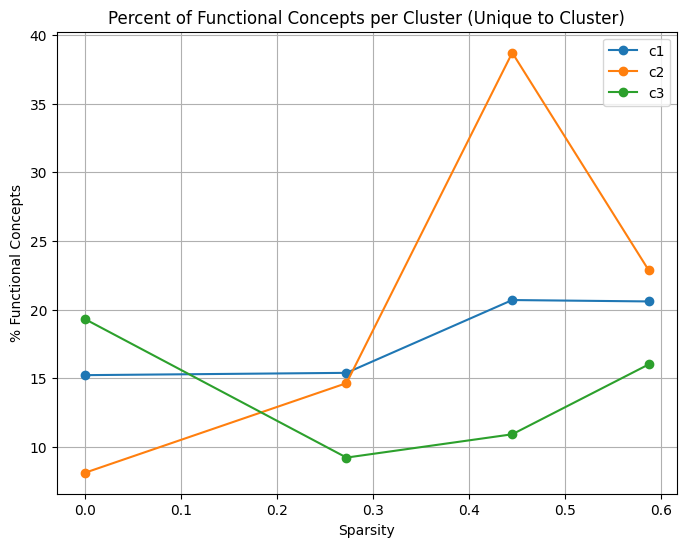

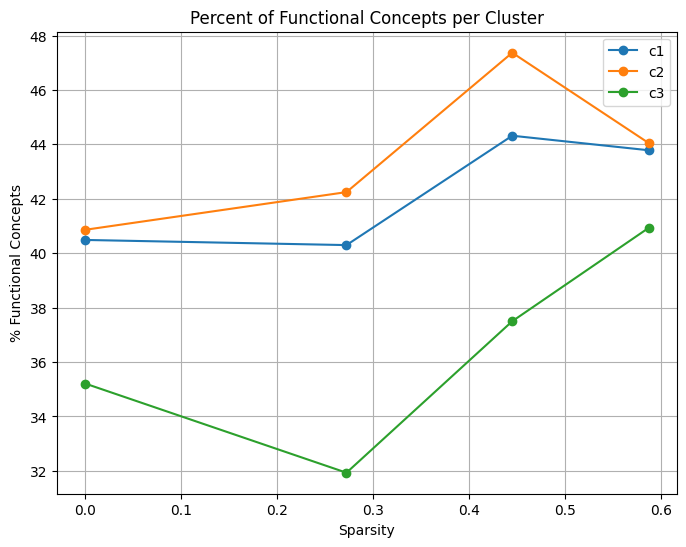

In [102]:
import matplotlib.pyplot as plt

def plot_func_percentages(sparsity_to_cluster_concepts, unique=False):
    """
    Plot percent of functional concepts per cluster vs sparsity.

    Parameters:
    - sparsity_to_cluster_concepts: dict[sparsity -> cluster -> set(concepts)]
    - unique: if True, counts only concepts unique to that cluster
    """
    sparsities = sorted(sparsity_to_cluster_concepts.keys())
    clusters = ['c1', 'c2', 'c3']

    # Prepare data for plotting
    func_percent = {c: [] for c in clusters}

    for s in sparsities:
        if s > 0.6: continue
        cluster_concepts = sparsity_to_cluster_concepts[s]

        # If unique=True, remove concepts that appear in other clusters at same sparsity
        if unique:
            all_concepts = set().union(*cluster_concepts.values())
            unique_concepts = {}
            for c in clusters:
                others = all_concepts - cluster_concepts[c]
                unique_concepts[c] = cluster_concepts[c] - others
            cluster_concepts = unique_concepts

        for c in clusters:
            concepts = cluster_concepts[c]
            if len(concepts) == 0:
                pct = 0
            else:
                func_count = sum(1 for x in concepts if label_concept(x) == 'c')
                pct = func_count / len(concepts)
            func_percent[c].append(pct * 100)  # convert to %
    
    # Plot
    plt.figure(figsize=(8,6))
    for c in clusters:
        plt.plot(sparsities[:-2], func_percent[c], marker='o', label=f"{c}")
    plt.xlabel("Sparsity")
    plt.ylabel("% Functional Concepts")
    title = "Percent of Functional Concepts per Cluster"
    if unique:
        title += " (Unique to Cluster)"
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
plot_func_percentages(sparsity_to_cluster_concepts_unique, unique=True)
plot_func_percentages(sparsity_to_cluster_concepts, unique=False)


these graphs say that: overall, pruning induces more generality in the final layer, but nonfunc concepts still become more prevalent at c3

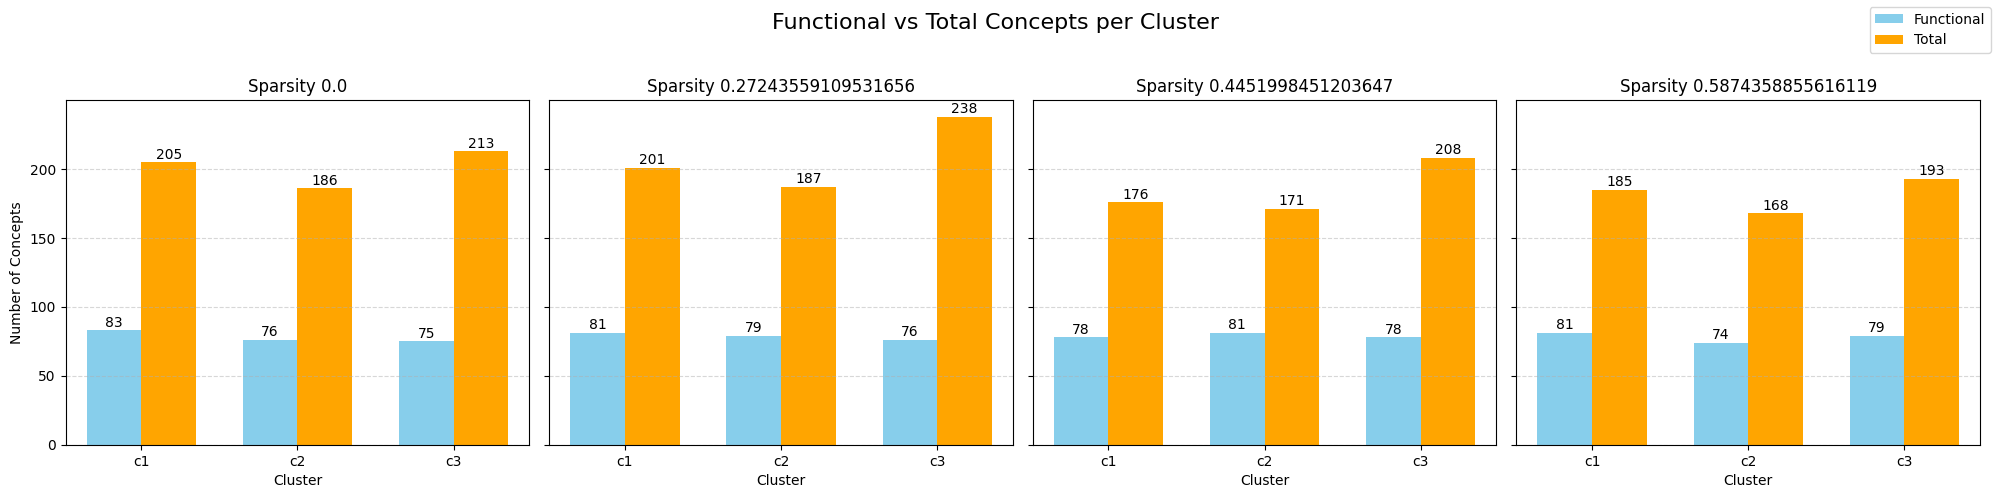

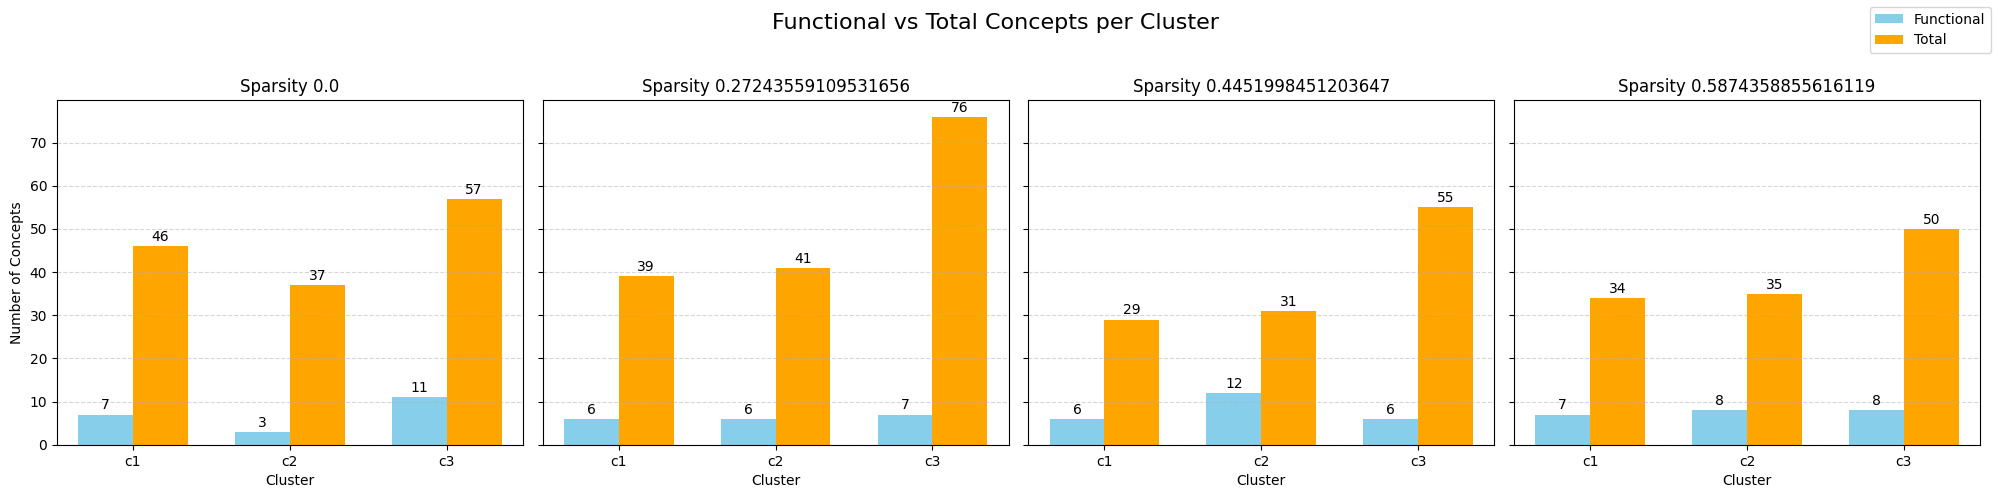

In [119]:
import matplotlib.pyplot as plt
import numpy as np

def plot_func_vs_total_grid(sparsity_to_cluster_concepts, unique=False):
    """
    Plot 4 subplots in a 1-row, 4-column grid showing functional vs total concepts per cluster,
    with numbers on top.
    
    Parameters:
    - sparsity_to_cluster_concepts: dict[sparsity -> cluster -> set(concepts)]
    - unique: if True, counts only concepts unique to that cluster
    """
    sparsities = sorted(sparsity_to_cluster_concepts.keys())[:4]  # pick first 4 sparsities
    clusters = ['c1', 'c2', 'c3']
    n_clusters = len(clusters)
    width = 0.35
    
    # 1 row, 4 columns
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    
    for i, s in enumerate(sparsities):
        ax = axes[i]
        
        cluster_concepts = sparsity_to_cluster_concepts[s]
        
        # Unique-to-cluster filter
        if unique:
            all_concepts = set().union(*cluster_concepts.values())
            unique_concepts = {}
            for c in clusters:
                others = all_concepts - cluster_concepts[c]
                unique_concepts[c] = cluster_concepts[c] - others
            cluster_concepts = unique_concepts
        
        func_counts = []
        total_counts = []
        for c in clusters:
            concepts = cluster_concepts[c]
            total_counts.append(len(concepts))
            func_counts.append(sum(1 for x in concepts if label_concept(x) == 'c'))
        
        x = np.arange(n_clusters)
        bars_func = ax.bar(x - width/2, func_counts, width, label='Functional', color='skyblue')
        bars_total = ax.bar(x + width/2, total_counts, width, label='Total', color='orange')
        
        # Numbers on top
        for bar in bars_func + bars_total:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)
        
        ax.set_xticks(x)
        ax.set_xticklabels(clusters)
        ax.set_xlabel("Cluster")
        ax.set_title(f"Sparsity {s}")
        ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    axes[0].set_ylabel("Number of Concepts")
    fig.suptitle("Functional vs Total Concepts per Cluster", fontsize=16)
    fig.legend(['Functional', 'Total'], loc='upper right')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Call the function
plot_func_vs_total_grid(sparsity_to_cluster_concepts, unique=False)
plot_func_vs_total_grid(sparsity_to_cluster_concepts_unique, unique=True)

In [16]:
from collections import Counter
def get_pis(root):
    pis =[]
    i=0
    for fldername in sorted(os.listdir(root)):
        print(fldername)
        try:
            pis.append(float(fldername.split("%")[0]))
            i+=1
        except:
            continue
    return pis
root='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls'
pis = get_pis(root)
for pi in pis:
    for c in [1,2,3]:
        try:
            path_to_cluster = os.path.join(root, f"{pi}%Pruned", f'Cluster{c}IOUS1024N.csv')
            all_unique_concepts_at_cluster, all_concpets_with_repeats = load_csv_data(path_to_cluster)
            redundancies = Counter(all_concpets_with_repeats)
            redundancies = [k for k,i in redundancies.items() if i > 1]

            print(f"% of redundancies at {pi} at {c} = {len(redundancies)/len(all_unique_concepts_at_cluster)}")
        except:
            continue
    print("="*80)
        
def collect_concepts_per_neuron_by_cluster(base_dir):
    """
    Returns:
    {
      method: {
        prune_pct: {
          cluster_id: {
            unit: set(concepts)
          }
        }
      }
    }
    """
    base_dir = Path(base_dir)
    results = defaultdict(
        lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(set)))
    )

    for method in ["CoFi", "lottery_ticket", "wanda"]:
 
        method_dir = base_dir / method
        
        if not method_dir.exists():
            continue

        for run_dir in method_dir.glob("Run0.25_new"):
            expls_dir = run_dir / "Expls"
            if not expls_dir.exists():
                continue

            for pruned_dir in expls_dir.iterdir():
                if not pruned_dir.is_dir():
                    continue

                # extract pruning percentage
                m = re.search(r"([\d.]+)%", pruned_dir.name)
                if m is None:
                    continue
                prune_pct = float(m.group(1))

                for csv_file in pruned_dir.glob("Cluster*.csv"):
                    cluster_id = csv_file.stem  # e.g. Cluster1IOUS1024N

                    unit_concepts = load_csv_data(csv_file)
                    
                    for unit, concepts in unit_concepts.items():
                        results[method][prune_pct][cluster_id][unit].update(concepts)

    return results
      

.ipynb_checkpoints
0.0%Pruned
0.27243559109531656%Pruned
0.4451998451203647%Pruned
0.5874358855616119%Pruned
0.6851741293419538%Pruned


In [132]:
import os
from collections import defaultdict, Counter

def load_cluster_concepts_from_csv(sparsity_dir):
    """
    Load concepts for c1, c2, c3 from CSVs in a given sparsity folder.
    Returns dict: cluster_name -> list(concepts)
    """
    cluster_files = [
        "Cluster1IOUS1024N.csv",
        "Cluster2IOUS1024N.csv",
        "Cluster3IOUS1024N.csv",
    ]
    cluster_concepts = {}
    for i, fname in enumerate(cluster_files, start=1):
        fpath = os.path.join(sparsity_dir, fname)
        try:
            unit_concepts = load_csv_data(fpath)  # your function: unit -> set(concepts)
            all_concepts = []
            for concepts in unit_concepts.values():
                all_concepts.extend(concepts)
            cluster_concepts[f'c{i}'] = all_concepts
        except Exception as e:
            print(f"Failed to load {fpath}: {e}")
            cluster_concepts[f'c{i}'] = []
    return cluster_concepts

def compute_func_nonfunc_redundancy(base_dir):
    """
    Load CSVs for each sparsity and cluster, compute average redundancy for functional vs non-functional concepts.
    
    Returns:
    - redundancy_stats[sparsity][cluster] = {
        'func_total': number of unique functional concepts,
        'func_avg_redundancy': average times each functional concept appears across clusters,
        'nonfunc_total': number of unique non-functional concepts,
        'nonfunc_avg_redundancy': average times each non-functional concept appears across clusters
      }
    """
    redundancy_stats = {}

    for sparsity in os.listdir(base_dir):
        sparsity_path = os.path.join(base_dir, sparsity)
        try:
            s = float(sparsity.split("%")[0])
            if s >0.6: continue
        except ValueError:
            continue

        cluster_concepts = load_cluster_concepts_from_csv(sparsity_path)
        redundancy_stats[s] = {}

        # Flatten all concepts across clusters to count redundancy
        all_concepts = []
        for concepts in cluster_concepts.values():
            all_concepts.extend(concepts)
        concept_counts = Counter(all_concepts)  # counts across all clusters

        for cluster_name, concepts in cluster_concepts.items():
            unique_func = set(c for c in concepts if label_concept(c) == 'c')
            unique_nonfunc = set(c for c in concepts if label_concept(c) != 'c')

            func_avg_redundancy = (sum(concept_counts[c] for c in unique_func) / len(unique_func)) if unique_func else 0
            nonfunc_avg_redundancy = (sum(concept_counts[c] for c in unique_nonfunc) / len(unique_nonfunc)) if unique_nonfunc else 0

            redundancy_stats[s][cluster_name] = {
                #'func_total': len(unique_func),
                'func_avg_redundancy': func_avg_redundancy,
                #'nonfunc_total': len(unique_nonfunc),
                'nonfunc_avg_redundancy': nonfunc_avg_redundancy
            }

    return redundancy_stats


redundancy_stats=compute_func_nonfunc_redundancy(base_dir)

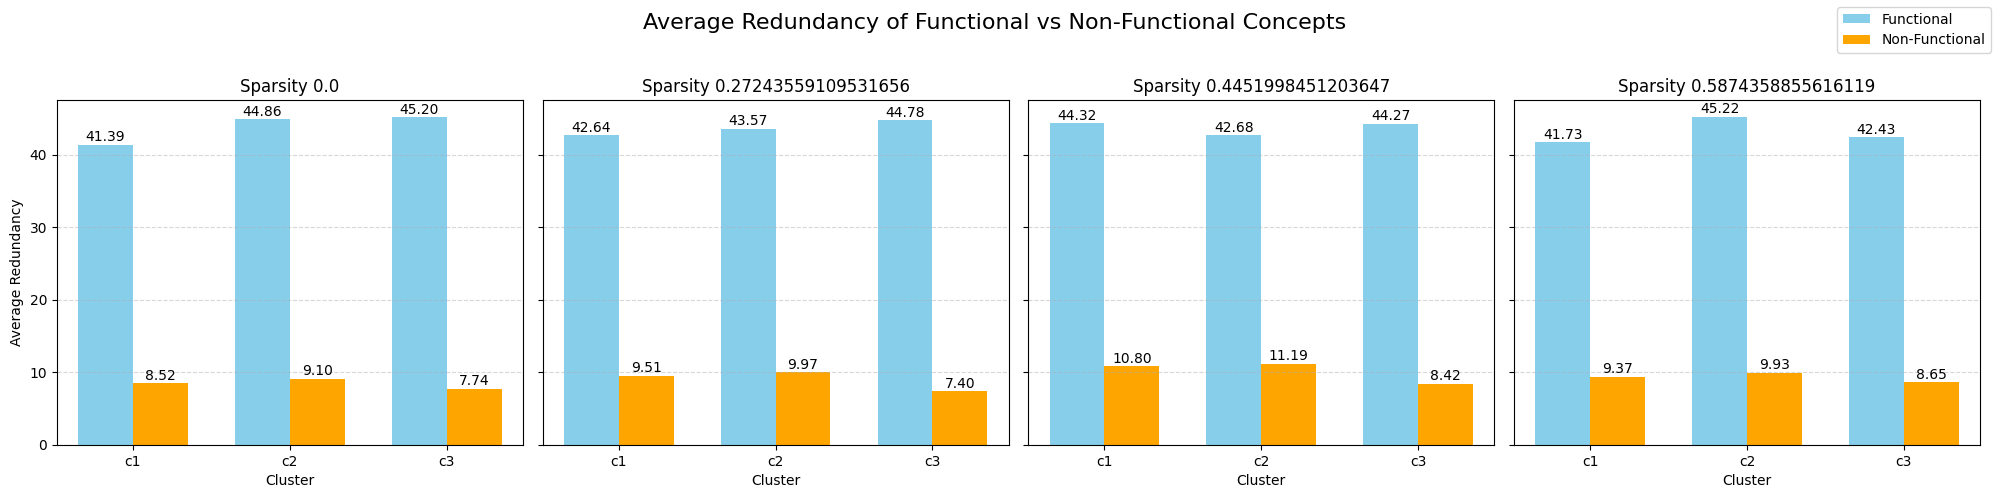

In [133]:
import matplotlib.pyplot as plt
import numpy as np

def plot_func_nonfunc_avg_redundancy(redundancy_stats):
    """
    Plot bar plots of average redundancy for functional vs non-functional concepts.
    
    Parameters:
    - redundancy_stats[sparsity][cluster] -> dict with 'func_avg_redundancy' and 'nonfunc_avg_redundancy'
    """
    sparsities = sorted(redundancy_stats.keys())[:4]  # first 4 sparsities
    clusters = ['c1', 'c2', 'c3']
    n_clusters = len(clusters)
    width = 0.35

    fig, axes = plt.subplots(1, 4, figsize=(20,5), sharey=True)
    axes = np.expand_dims(axes, axis=0)  # make axes[0][i] style

    for i, s in enumerate(sparsities):
        ax = axes[0][i]

        func_avg = [redundancy_stats[s][c]['func_avg_redundancy'] for c in clusters]
        nonfunc_avg = [redundancy_stats[s][c]['nonfunc_avg_redundancy'] for c in clusters]

        x = np.arange(n_clusters)
        bars_func = ax.bar(x - width/2, func_avg, width, color='skyblue', label='Functional')
        bars_nonfunc = ax.bar(x + width/2, nonfunc_avg, width, color='orange', label='Non-Functional')

        # Annotate numbers on top of bars
        for bar in bars_func + bars_nonfunc:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.2f}',
                    ha='center', va='bottom', fontsize=10)

        ax.set_xticks(x)
        ax.set_xticklabels(clusters)
        ax.set_xlabel("Cluster")
        ax.set_title(f"Sparsity {s}")
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    axes[0][0].set_ylabel("Average Redundancy")
    fig.suptitle("Average Redundancy of Functional vs Non-Functional Concepts", fontsize=16)
    fig.legend(['Functional', 'Non-Functional'], loc='upper right')
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
plot_func_nonfunc_avg_redundancy(redundancy_stats)

In [17]:
concepts_by_cluster = collect_concepts_per_neuron_by_cluster(base_dir='/workspace/CCE_NLI/BERT/exp/')
def get_pis(root):
    pis =[]
    i=0
    for fldername in sorted(os.listdir(root)):
        print(fldername)
        try:
            pis.append(float(fldername.split("%")[0]))
            i+=1
        except:
            continue
    return pis

pis = get_pis(root='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_new/Expls')
def neuron_count_table(concepts_by_cluster):
    """
    Input:
      concepts_by_cluster[method][prune_pct][cluster_id][neuron] = set(concepts)

    Output:
      pandas DataFrame with rows = sparsity levels,
      columns = methods (cofi, lottery_ticket, wanda),
      values = "c1:10 c2:5 c3:1"
    """
    rows = defaultdict(dict)
    
    finallay_neurons =[1024,1022,1022,1022,1020]
    totals={pi:fn for pi,fn in zip(pis, finallay_neurons)}
    #totals={0.0: 1024,0.25:768, 0.4404:573, 0.579: 431, 0.6884:319, 0.7695:256}
    print(totals)
    for method, method_data in concepts_by_cluster.items():
        if method in ['lottery_ticket', 'wanda']:
            total=1024
        for prune_pct, prune_data in method_data.items():
            cluster_counts = []


            if method not in ['lottery_ticket', 'wanda']:
                total = totals[prune_pct]

            for cluster_id, neuron_map in prune_data.items():
                # extract cluster number (Cluster1, Cluster2, ...)
                m = re.search(r"Cluster(\d+)", cluster_id)
                cluster_name = f"c{m.group(1)}" if m else cluster_id

                n_neurons = len(neuron_map)
                cluster_counts.append(f"{cluster_name}:{100*n_neurons/total}")

            # sort c1, c2, c3
            cluster_counts = sorted(
                cluster_counts,
                key=lambda x: int(re.search(r"\d+", x).group())
            )
            print(f"prune_pct: {prune_pct} \t cluster counts: {cluster_counts}")
            rows[prune_pct][method] = " ".join(cluster_counts)

    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index.name = "sparsity"
    df = df.sort_index()

    return df
neuron_count_table(concepts_by_cluster)

.ipynb_checkpoints
0.0%Pruned
0.27243559109531656%Pruned
0.4451998451203647%Pruned
0.5874358855616119%Pruned
0.6851741293419538%Pruned
{0.0: 1024, 0.27243559109531656: 1022, 0.4451998451203647: 1022, 0.5874358855616119: 1022, 0.6851741293419538: 1020}
prune_pct: 0.0 	 cluster counts: ['c1:59.9609375', 'c2:57.03125', 'c3:50.87890625']
prune_pct: 0.27243559109531656 	 cluster counts: ['c1:61.154598825831705', 'c2:58.806262230919764', 'c3:53.62035225048923']
prune_pct: 0.4451998451203647 	 cluster counts: ['c1:60.95890410958904', 'c2:58.806262230919764', 'c3:53.32681017612524']
prune_pct: 0.5874358855616119 	 cluster counts: ['c1:58.02348336594912', 'c2:56.0665362035225', 'c3:51.076320939334636']
prune_pct: 0.6851741293419538 	 cluster counts: ['c1:60.88235294117647', 'c2:58.529411764705884']


,CoFi
sparsity,
0.000000,c1:59.9609375 c2:57.03125 c3:50.87890625
0.272436,c1:61.154598825831705 c2:58.806262230919764 c3...
0.445200,c1:60.95890410958904 c2:58.806262230919764 c3:...
0.587436,c1:58.02348336594912 c2:56.0665362035225 c3:51...
0.685174,c1:60.88235294117647 c2:58.529411764705884


In [27]:
#bowman becomes signficantly more explainable (2% to 23% neurons explainable vs 1.6% to 4.2% or 3.2%) with cofi pruning over lth, wanda

In [18]:
def concept_counts_by_sparsity(concepts_by_cluster, method="CoFi", cluster_num=1, global_=False):
    """
    Returns:
    {
      sparsity: {
        concept: redundancy_count
      }
    }
    """
    cluster_pattern = re.compile(rf"Cluster{cluster_num}IOUS1024N.csv\b")

    result = {}

    for sparsity, clusters in concepts_by_cluster.get(method, {}).items():
        concept_counter = defaultdict(int)

        for cluster_id, neuron_map in clusters.items():
            if not global_ and f'{cluster_num}IOUS' not in cluster_id: continue

            for neuron, concepts in neuron_map.items():
                for concept in concepts:
                    concept_counter[concept] += 1

        result[sparsity] = sum(list(concept_counter.values()))/len(concept_counter)

    return result


In [84]:
concept_counts_by_sparsity(concepts_by_cluster, method="wanda", cluster_num=1)

{25.0: 1.5348837209302326,
 43.75: 1.446808510638298,
 57.812: 1.8571428571428572,
 68.359: 1.6779661016949152,
 76.27: 1.8793103448275863,
 0.0: 1.7037037037037037}

In [85]:
concept_counts_by_sparsity(concepts_by_cluster, method="wanda", cluster_num=2)

{25.0: 1.5588235294117647,
 43.75: 1.7352941176470589,
 57.812: 1.6129032258064515,
 68.359: 1.6111111111111112,
 76.27: 1.5813953488372092,
 0.0: 1.6333333333333333}

In [86]:
concept_counts_by_sparsity(concepts_by_cluster, method="wanda", cluster_num=3)

{25.0: 1.3333333333333333,
 43.75: 1.7777777777777777,
 57.812: 1.619047619047619,
 68.359: 1.7647058823529411,
 76.27: 1.7222222222222223,
 0.0: 1.0}

In [87]:
concept_counts_by_sparsity(concepts_by_cluster, method="wanda", cluster_num=3, global_=True)

{25.0: 2.1384615384615384,
 43.75: 2.338235294117647,
 57.812: 2.6140350877192984,
 68.359: 2.367088607594937,
 76.27: 2.4761904761904763,
 0.0: 2.1020408163265305}

In [46]:
critical_tokens =  [
    "a", "an", "the", "this", "that", "these", "those",
    "some", "any", "each", "every", "no",
    "i", "you", "he", "she", "it", "they",
    "me", "him", "her", "them",
    "his", "hers", "their", "its",
    "someone", "something", "nobody",
    "in", "on", "at", "by", "for", "from", "to", "with",
    "about", "into", "through", "over", "under",
    "between", "near", "inside", "outside",
    "and", "or", "but", "because", "while", "if", "though", "although", "so",
    "is", "am", "are", "was", "were", "be", "being", "been",
    "do", "does", "did",
    "have", "has", "had",
    "can", "could", "will", "would", "should", "may", "might", "must",
    "not", "none", "never", "nothing", "least", "most", "all",
    "there", "here", "just", "only", "also", "very",
    ".", ",", ":", ";", "!", "?"
]


def label_concept(concept: str):
    """
    Returns 'c' for critical or 'nc' for non-critical
    """
    # POS tags are always critical
    if ":tag:" in concept:
        return "c"

    # Overlap / structural features
    if concept.startswith("oth:"):
        return "c"

    # Token-level concepts
    if ":tok:" in concept:
        token = concept.split(":tok:")[-1]
        return "c" if token in critical_tokens else "nc"

    # Default fallback
    return "nc"


def annotate_concepts(concept_set):
    annotated = {}
    num_critical = 0
    num_noncritical = 0

    for concept in sorted(concept_set):
        label = label_concept(concept)
        annotated[concept] = label

        if label == "c":
            num_critical += 1
        else:
            num_noncritical += 1


    return num_critical, num_noncritical, annotated

annotate_concepts(all_cps_fl)

(90,
 166,
 {'hyp:tag:,': 'c',
  'hyp:tag:.': 'c',
  'hyp:tag:cc': 'c',
  'hyp:tag:cd': 'c',
  'hyp:tag:dt': 'c',
  'hyp:tag:ex': 'c',
  'hyp:tag:in': 'c',
  'hyp:tag:jj': 'c',
  'hyp:tag:nn': 'c',
  'hyp:tag:nnp': 'c',
  'hyp:tag:nns': 'c',
  'hyp:tag:prp': 'c',
  'hyp:tag:prp$': 'c',
  'hyp:tag:rb': 'c',
  'hyp:tag:rp': 'c',
  'hyp:tag:vb': 'c',
  'hyp:tag:vbd': 'c',
  'hyp:tag:vbg': 'c',
  'hyp:tag:vbn': 'c',
  'hyp:tag:vbp': 'c',
  'hyp:tag:vbz': 'c',
  "hyp:tok:'s": 'nc',
  'hyp:tok:all': 'c',
  'hyp:tok:and': 'c',
  'hyp:tok:are': 'c',
  'hyp:tok:around': 'nc',
  'hyp:tok:as': 'nc',
  'hyp:tok:at': 'c',
  'hyp:tok:ball': 'nc',
  'hyp:tok:bathroom': 'nc',
  'hyp:tok:beach': 'nc',
  'hyp:tok:bike': 'nc',
  'hyp:tok:boy': 'nc',
  'hyp:tok:by': 'c',
  'hyp:tok:car': 'nc',
  'hyp:tok:child': 'nc',
  'hyp:tok:children': 'nc',
  'hyp:tok:dinner': 'nc',
  'hyp:tok:dog': 'nc',
  'hyp:tok:dogs': 'nc',
  'hyp:tok:doing': 'nc',
  'hyp:tok:down': 'nc',
  'hyp:tok:drinking': 'nc',
  'hyp:tok:e

In [56]:
def collect_cluster_concepts_at_sparsity(
    concepts_by_cluster,
    method='lottery_ticket',
    sparsity=0.25,
    cluster_num=3
):
    """
    Returns:
        set of all unique concepts in Cluster{cluster_num}
        for a given sparsity across all neurons
    """
    cluster_key = f"Cluster{cluster_num}"
    all_concepts = set()

    # Get only the requested sparsity
    clusters_at_sparsity = concepts_by_cluster.get(method, {}).get(sparsity, {})

    for cluster_id, neuron_map in clusters_at_sparsity.items():
        if not cluster_id.startswith(cluster_key):
            continue

        for neuron, concepts in neuron_map.items():
            all_concepts.update(concepts)

    return all_concepts
c1_percentfunctional =[]
c2_percentfunctional =[]
c3_percentfunctional =[]
global_func=[]
for sp in pis:
    c3 = collect_cluster_concepts_at_sparsity(concepts_by_cluster, sparsity=sp, method='CoFi', cluster_num=3)
    c2 = collect_cluster_concepts_at_sparsity(concepts_by_cluster, sparsity=sp,method='CoFi', cluster_num=2)
    c1 = collect_cluster_concepts_at_sparsity(concepts_by_cluster, sparsity=sp, method='CoFi', cluster_num=1)
    all_cps_fl = set(c1).union(set(c2)).union(set(c3))
    c,nc, _ = annotate_concepts(all_cps_fl)
    onlyc1=set(c1)-set(c2)-set(c3)
    onlyc2=set(c2)-set(c1)-set(c3)
    onlyc3=set(c3)-set(c1)-set(c2)
    c1n,nc1, _ = annotate_concepts(c1)
    c1_percentfunctional.append(100*c1n/(c1n+nc1))
    c2n,nc2, _ = annotate_concepts(c2)
    c2_percentfunctional.append(100*c2n/(c2n+nc2))
    
    c3n,nc3, _ = annotate_concepts(c3)
    c3_percentfunctional.append(100*c3n/(c3n+nc3))
    
    global_func.append(100*c/(c+nc))
    print(f'Sparsity {sp}, Percent of foundational concepts in c1 : {100*c1n/(c1n+nc1)}% calculated on {len(set(c1))} concepts')    
    print(f'Sparsity {sp}, Percent of foundational concepts in c2: {100*c2n/(c2n+nc2)}% calculated on {len(set(c2))} concepts')    
    print(f'Sparsity {sp}, Percent of foundational concepts in c3: {100*c3n/(c3n+nc3)}% calculated on {len(set(c3))} concepts')    
    print(f'Sparsity {sp}, Percent of foundational concepts globally : {100*c/(c+nc)}% calculated on {len(set(all_cps_fl))} concepts')
    


Sparsity 0.0, Percent of foundational concepts in c1 : 40.48780487804878% calculated on 205 concepts
Sparsity 0.0, Percent of foundational concepts in c2: 40.86021505376344% calculated on 186 concepts
Sparsity 0.0, Percent of foundational concepts in c3: 35.2112676056338% calculated on 213 concepts
Sparsity 0.0, Percent of foundational concepts globally : 30.721003134796238% calculated on 319 concepts
Sparsity 0.27243559109531656, Percent of foundational concepts in c1 : 40.298507462686565% calculated on 201 concepts
Sparsity 0.27243559109531656, Percent of foundational concepts in c2: 42.24598930481283% calculated on 187 concepts
Sparsity 0.27243559109531656, Percent of foundational concepts in c3: 31.932773109243698% calculated on 238 concepts
Sparsity 0.27243559109531656, Percent of foundational concepts globally : 29.04191616766467% calculated on 334 concepts
Sparsity 0.4451998451203647, Percent of foundational concepts in c1 : 44.31818181818182% calculated on 176 concepts
Sparsity

ZeroDivisionError: division by zero

In [40]:
c1_percentfunctional
c2_percentfunctional
c3_percentfunctional
c3_percentfunctional,c2_percentfunctional,c1_percentfunctional
global_func

In [37]:
all_cps_fl

{'hyp:tag:.',
 'hyp:tag:dt',
 'hyp:tag:ex',
 'hyp:tag:in',
 'hyp:tag:nn',
 'hyp:tag:prp',
 'hyp:tag:prp$',
 'hyp:tag:vb',
 'hyp:tag:vbg',
 'hyp:tok:about',
 'hyp:tok:after',
 'hyp:tok:asleep',
 'hyp:tok:cat',
 'hyp:tok:dancing',
 'hyp:tok:driving',
 'hyp:tok:eating',
 'hyp:tok:empty',
 'hyp:tok:for',
 'hyp:tok:funny',
 'hyp:tok:home',
 'hyp:tok:human',
 'hyp:tok:in',
 'hyp:tok:inside',
 'hyp:tok:is',
 'hyp:tok:moving',
 'hyp:tok:near',
 'hyp:tok:no',
 'hyp:tok:nobody',
 'hyp:tok:outdoors',
 'hyp:tok:outside',
 'hyp:tok:park',
 'hyp:tok:people',
 'hyp:tok:person',
 'hyp:tok:running',
 'hyp:tok:sitting',
 'hyp:tok:sleeping',
 'hyp:tok:something',
 'hyp:tok:swimming',
 'hyp:tok:tall',
 'hyp:tok:there',
 'hyp:tok:to',
 'hyp:tok:walking',
 'oth:overlap:overlap25',
 'oth:overlap:overlap50',
 'oth:overlap:overlap75',
 'pre:tag:.',
 'pre:tag:nn',
 'pre:tag:nns',
 'pre:tok:dog',
 'pre:tok:girl',
 'pre:tok:his',
 'pre:tok:men',
 'pre:tok:opposing',
 'pre:tok:sleeping'}

In [16]:
onlyc2

{'hyp:tok:are',
 'hyp:tok:birthday',
 'hyp:tok:bowling',
 'hyp:tok:chasing',
 'hyp:tok:day',
 'hyp:tok:drives',
 'hyp:tok:football',
 'hyp:tok:from',
 'hyp:tok:funny',
 'hyp:tok:ice',
 'hyp:tok:just',
 'hyp:tok:least',
 'hyp:tok:multiple',
 'hyp:tok:new',
 'hyp:tok:not',
 'hyp:tok:sad',
 'hyp:tok:sister',
 'hyp:tok:skateboard',
 'hyp:tok:soccer',
 'hyp:tok:son',
 'hyp:tok:table',
 'hyp:tok:tv',
 'hyp:tok:volleyball',
 'hyp:tok:wife',
 'pre:tok:!',
 'pre:tok:basketball',
 'pre:tok:dog',
 'pre:tok:opposing',
 'pre:tok:racket',
 'pre:tok:sleeping',
 'pre:tok:volleyball'}

In [17]:
onlyc1 #cps at c1 but not c2,c3 (at all sparsities)

{'hyp:tag:vbz',
 'hyp:tok:basketball',
 'hyp:tok:bicycle',
 'hyp:tok:black',
 'hyp:tok:competing',
 'hyp:tok:concert',
 'hyp:tok:dog',
 'hyp:tok:eats',
 'hyp:tok:empty',
 'hyp:tok:father',
 'hyp:tok:instrument',
 'hyp:tok:into',
 'hyp:tok:is',
 'hyp:tok:lady',
 'hyp:tok:man',
 'hyp:tok:men',
 'hyp:tok:next',
 'hyp:tok:on',
 'hyp:tok:playing',
 'hyp:tok:riding',
 'hyp:tok:sits',
 'hyp:tok:train',
 'hyp:tok:vacation',
 'hyp:tok:watching',
 'hyp:tok:while',
 'hyp:tok:woman',
 'pre:tag::',
 'pre:tag:cc',
 'pre:tag:in',
 'pre:tag:jj',
 'pre:tag:nns',
 'pre:tag:to',
 'pre:tag:vbg',
 'pre:tag:vbz',
 'pre:tok:about',
 'pre:tok:at',
 'pre:tok:ball',
 'pre:tok:beach',
 'pre:tok:blue',
 'pre:tok:boy',
 'pre:tok:car',
 'pre:tok:football',
 'pre:tok:from',
 'pre:tok:girl',
 'pre:tok:her',
 'pre:tok:his',
 'pre:tok:in',
 'pre:tok:man',
 'pre:tok:men',
 'pre:tok:people',
 'pre:tok:picture',
 'pre:tok:player',
 'pre:tok:players',
 'pre:tok:running',
 'pre:tok:someone',
 'pre:tok:their',
 'pre:tok:thro